In [1]:
import allel

In [2]:
vcf = allel.read_vcf(
    r"C:\Users\PC\OneDrive\Desktop\data\ALL.chr20.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz",
    region="20:1-5000000",
    fields=["samples", "calldata/GT", "variants/POS"]
)

In [3]:
print(vcf["calldata/GT"].shape)

(150174, 2504, 2)


In [4]:
print(vcf.keys())

dict_keys(['samples', 'calldata/GT', 'variants/POS'])


In [5]:
print(vcf["calldata/GT"].shape)

(150174, 2504, 2)


In [6]:
gt = vcf["calldata/GT"][:10000, :100]

In [7]:
print(gt.shape)

(10000, 100, 2)


In [8]:
gn = gt[:, :, 0] + gt[:, :, 1]

In [9]:
print(gn.shape)

(10000, 100)


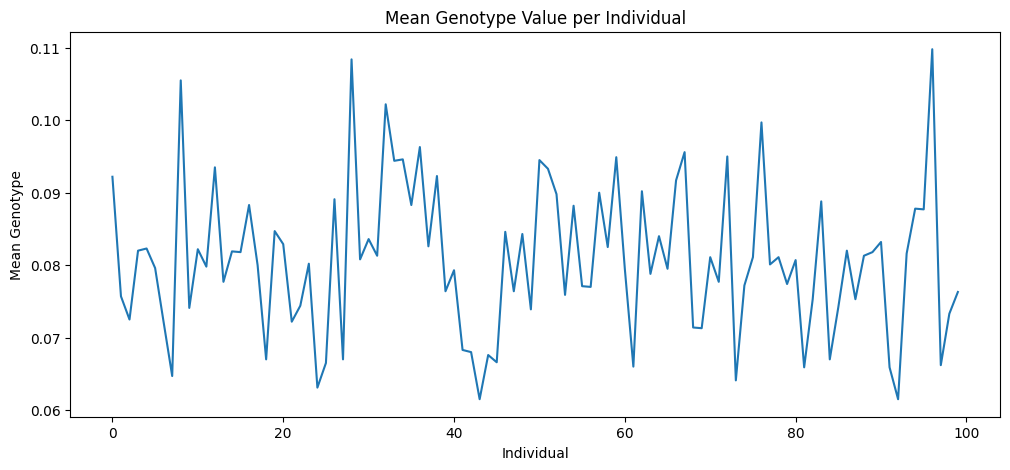

In [10]:
import matplotlib.pyplot as plt
import numpy as np

mean_genotype = np.mean(gn, axis=0)

plt.figure(figsize=(12,5))
plt.plot(mean_genotype)
plt.title("Mean Genotype Value per Individual")
plt.xlabel("Individual")
plt.ylabel("Mean Genotype")
plt.show()

In [11]:
degraded = gn.copy()

mask = np.random.rand(*degraded.shape) < 0.3
degraded[mask] = -1

In [12]:
missing_rate = np.mean(degraded == -1)

print("Missing rate:", missing_rate)

Missing rate: 0.299536


In [13]:
reference = gn.T
query = degraded.T

In [14]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(query, reference)

In [15]:
predicted = similarity_matrix.argmax(axis=1)

In [16]:
true_ids = np.arange(reference.shape[0])

accuracy = np.mean(predicted == true_ids)

print("Identification accuracy:", accuracy)

Identification accuracy: 1.0


In [17]:
degradation_levels = [0.1, 0.3, 0.5, 0.7, 0.9]
accuracies = []

for level in degradation_levels:

    degraded = gn.copy()

    mask = np.random.rand(*degraded.shape) < level
    degraded[mask] = -1

    reference = gn.T
    query = degraded.T

    similarity_matrix = cosine_similarity(query, reference)

    predicted = similarity_matrix.argmax(axis=1)

    true_ids = np.arange(reference.shape[0])

    accuracy = np.mean(predicted == true_ids)

    accuracies.append(accuracy)

    print(f"Degradation {level:.1f} -> Accuracy {accuracy:.3f}")

Degradation 0.1 -> Accuracy 1.000
Degradation 0.3 -> Accuracy 1.000
Degradation 0.5 -> Accuracy 1.000
Degradation 0.7 -> Accuracy 0.400
Degradation 0.9 -> Accuracy 0.040


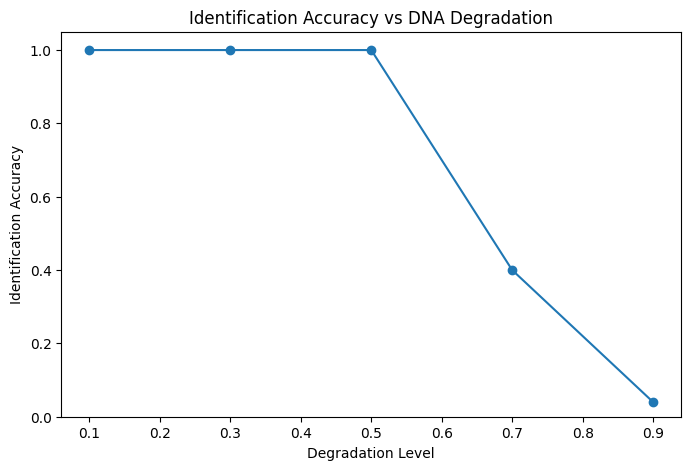

In [18]:
plt.figure(figsize=(8,5))

plt.plot(degradation_levels, accuracies, marker='o')

plt.title("Identification Accuracy vs DNA Degradation")
plt.xlabel("Degradation Level")
plt.ylabel("Identification Accuracy")

plt.ylim(0, 1.05)

plt.show()

In [19]:
plt.savefig("degradation_accuracy_curve.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [20]:

mix_1 = 0.7 * gn[:, 0] + 0.3 * gn[:, 1]
mix_2 = 0.5 * gn[:, 2] + 0.5 * gn[:, 3]
mix_3 = 0.9 * gn[:, 4] + 0.1 * gn[:, 5]

mixed_samples = np.vstack([mix_1, mix_2, mix_3])

print(mixed_samples.shape)

(3, 10000)


In [21]:
reference = gn.T

mix_similarity = cosine_similarity(mixed_samples, reference)

top_matches = np.argsort(mix_similarity, axis=1)[:, -5:][:, ::-1]

print(top_matches)

[[ 0  1 90 30 14]
 [ 3 13 31  1 78]
 [ 4 13 11  1  0]]


In [22]:
for i, matches in enumerate(top_matches):
    print(f"Mixture {i+1} top matches:", matches)

Mixture 1 top matches: [ 0  1 90 30 14]
Mixture 2 top matches: [ 3 13 31  1 78]
Mixture 3 top matches: [ 4 13 11  1  0]


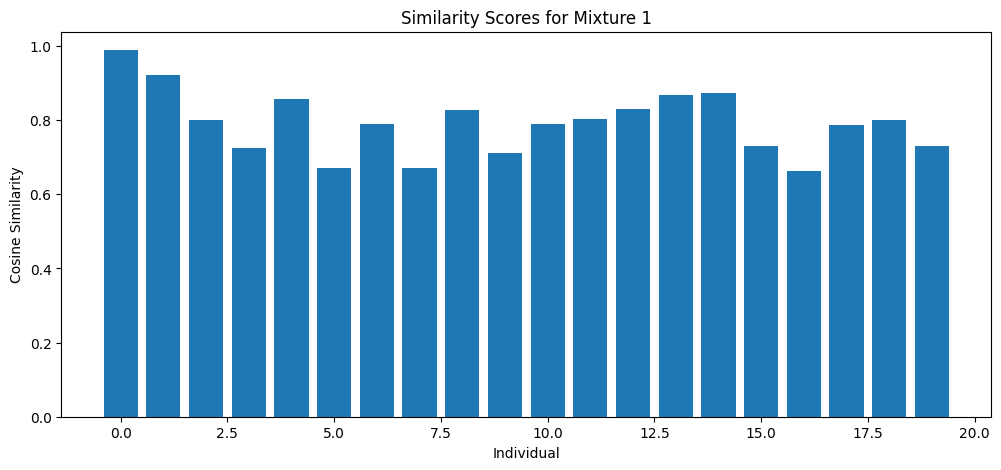

In [23]:
plt.figure(figsize=(12,5))

plt.bar(range(20), mix_similarity[0][:20])

plt.title("Similarity Scores for Mixture 1")
plt.xlabel("Individual")
plt.ylabel("Cosine Similarity")

plt.show()

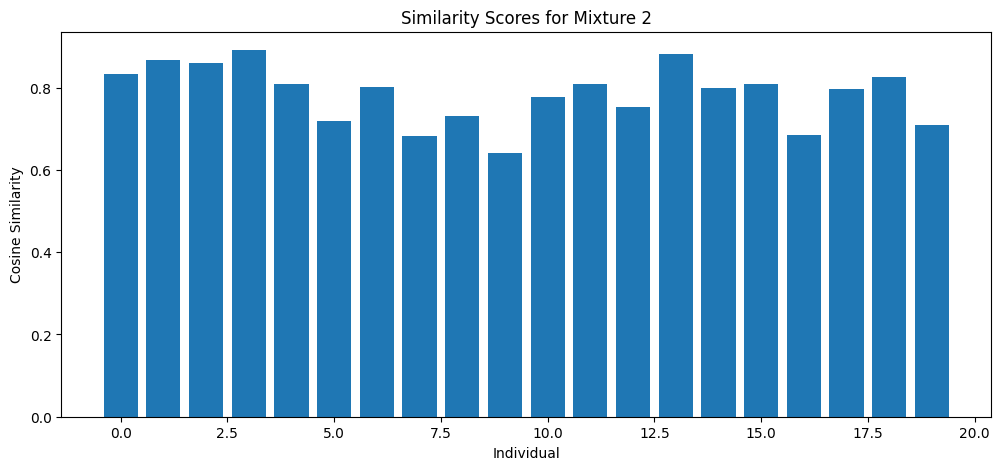

In [24]:
plt.figure(figsize=(12,5))

plt.bar(range(20), mix_similarity[1][:20])

plt.title("Similarity Scores for Mixture 2")
plt.xlabel("Individual")
plt.ylabel("Cosine Similarity")

plt.show()

In [25]:
from sklearn.decomposition import PCA

In [26]:
combined = np.vstack([reference, mixed_samples])

pca = PCA(n_components=2)

pca_result = pca.fit_transform(combined)

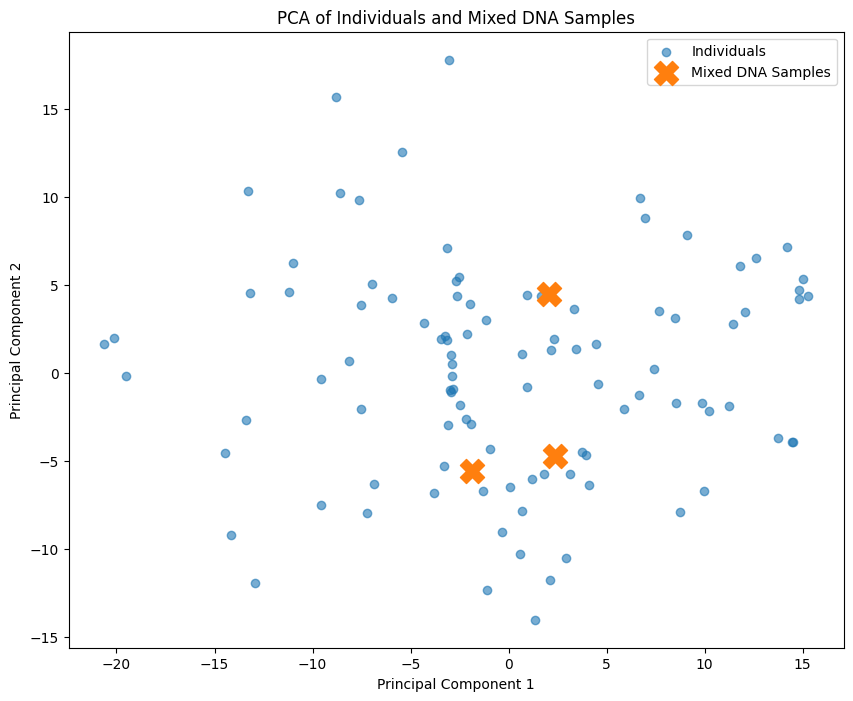

In [27]:
plt.figure(figsize=(10,8))

plt.scatter(
    pca_result[:100, 0],
    pca_result[:100, 1],
    alpha=0.6,
    label="Individuals"
)

plt.scatter(
    pca_result[100:, 0],
    pca_result[100:, 1],
    s=300,
    marker='X',
    label="Mixed DNA Samples"
)

plt.title("PCA of Individuals and Mixed DNA Samples")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend()

plt.show()

In [28]:
top_scores = np.sort(mix_similarity, axis=1)[:, -2:]

confidence = top_scores[:, 1] - top_scores[:, 0]

print(confidence)

[0.06726477 0.00882973 0.10089189]


In [29]:
for i, c in enumerate(confidence):
    print(f"Mixture {i+1} confidence: {abs(c):.4f}")

Mixture 1 confidence: 0.0673
Mixture 2 confidence: 0.0088
Mixture 3 confidence: 0.1009


In [30]:
from scipy.stats import entropy

In [31]:
probabilities = mix_similarity / mix_similarity.sum(axis=1, keepdims=True)

entropies = entropy(probabilities, axis=1)

print(entropies)

[4.60085189 4.60172211 4.59995946]


In [32]:
temperature = 0.05

scaled = np.exp(mix_similarity / temperature)

probabilities_sharp = scaled / scaled.sum(axis=1, keepdims=True)

sharp_entropy = entropy(probabilities_sharp, axis=1)

print(sharp_entropy)

[3.35644884 4.09525265 3.03051138]


In [33]:
for i, e in enumerate(sharp_entropy):
    print(f"Mixture {i+1} sharp entropy: {e:.4f}")

Mixture 1 sharp entropy: 3.3564
Mixture 2 sharp entropy: 4.0953
Mixture 3 sharp entropy: 3.0305


In [34]:
ratios = [0.5, 0.6, 0.7, 0.8, 0.9]

entropies = []
confidences = []

for r in ratios:

    mix = r * gn[:, 0] + (1-r) * gn[:, 1]

    mix = mix.reshape(1, -1)

    similarity = cosine_similarity(mix, reference)

    top_scores = np.sort(similarity, axis=1)[:, -2:]

    confidence = top_scores[:, 1] - top_scores[:, 0]

    scaled = np.exp(similarity / 0.05)

    probs = scaled / scaled.sum(axis=1, keepdims=True)

    e = entropy(probs, axis=1)

    confidences.append(abs(confidence[0]))
    entropies.append(e[0])

    print(f"Ratio {r:.1f}/{1-r:.1f} -> Confidence {confidence[0]:.4f}, Entropy {e[0]:.4f}")

Ratio 0.5/0.5 -> Confidence 0.0095, Entropy 3.5204
Ratio 0.6/0.4 -> Confidence 0.0389, Entropy 3.4684
Ratio 0.7/0.3 -> Confidence 0.0673, Entropy 3.3564
Ratio 0.8/0.2 -> Confidence 0.0944, Entropy 3.2035
Ratio 0.9/0.1 -> Confidence 0.1164, Entropy 3.0286


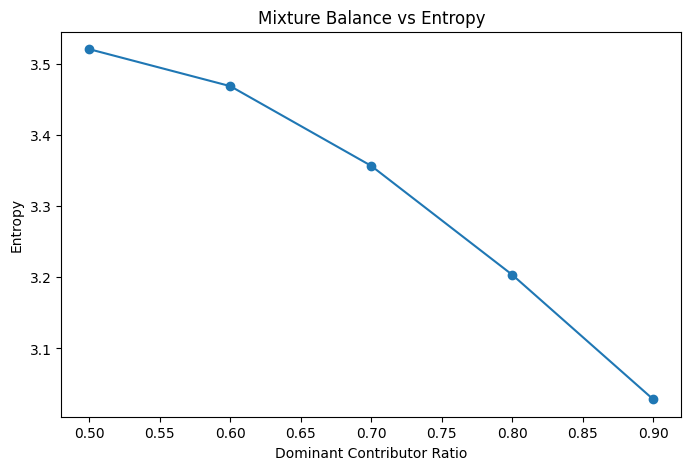

In [35]:
plt.figure(figsize=(8,5))

plt.plot(ratios, entropies, marker='o')

plt.title("Mixture Balance vs Entropy")
plt.xlabel("Dominant Contributor Ratio")
plt.ylabel("Entropy")

plt.show()

In [36]:
X = gn.T
y = np.arange(X.shape[0])

print(X.shape)
print(y.shape)

(100, 10000)
(100,)


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [38]:
import torch
import torch.nn as nn
import torch.optim as optim

In [39]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [40]:
class GenomicClassifier(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(10000, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 100)
        )

    def forward(self, x):
        return self.network(x)

In [41]:
model = GenomicClassifier()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [42]:
epochs = 50

losses = []

for epoch in range(epochs):
    model.train()

    optimizer.zero_grad()

    outputs = model(X_train_tensor)

    loss = criterion(outputs, y_train_tensor)

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 10/50, Loss: 3.1195
Epoch 20/50, Loss: 0.8505
Epoch 30/50, Loss: 0.0764
Epoch 40/50, Loss: 0.0101
Epoch 50/50, Loss: 0.0033


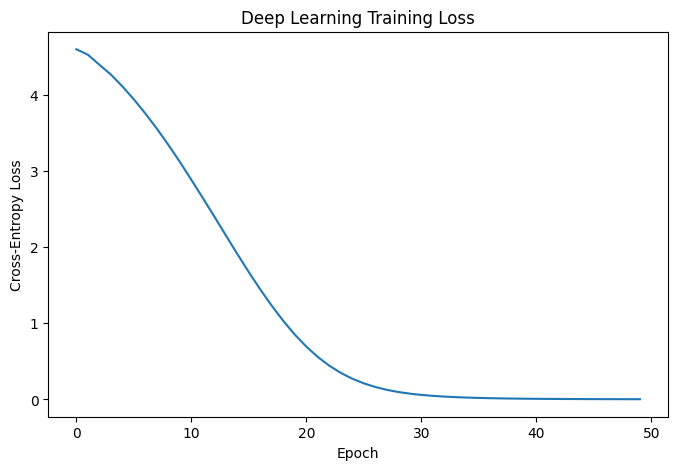

In [43]:
plt.figure(figsize=(8,5))
plt.plot(losses)
plt.title("Deep Learning Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.show()

In [44]:
model.eval()

with torch.no_grad():
    test_outputs = model(X_test_tensor)
    predictions = torch.argmax(test_outputs, dim=1)

accuracy = (predictions == y_test_tensor).float().mean().item()

print("Deep learning test accuracy:", accuracy)

Deep learning test accuracy: 0.0


In [45]:
embeddings = model.network[:-1](X_train_tensor).detach().numpy()

print(embeddings.shape)

(80, 128)


In [46]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

embedding_pca = pca.fit_transform(embeddings)

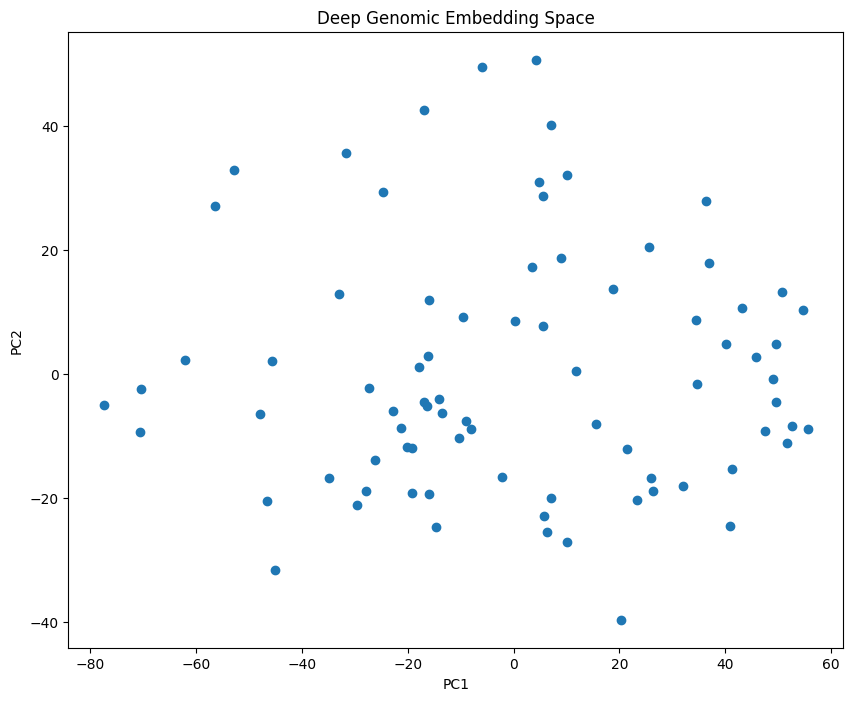

In [47]:
plt.figure(figsize=(10,8))

plt.scatter(
    embedding_pca[:,0],
    embedding_pca[:,1]
)

plt.title("Deep Genomic Embedding Space")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [48]:
import os

os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

In [49]:
plt.savefig("figures/nazwa_wykresu.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [50]:
import pandas as pd

degradation_results = pd.DataFrame({
    "degradation_level": degradation_levels,
    "identification_accuracy": accuracies
})

degradation_results.to_csv("results/degradation_results.csv", index=False)

mixture_results = pd.DataFrame({
    "dominant_contributor_ratio": ratios,
    "confidence": confidences,
    "entropy": entropies
})

mixture_results.to_csv("results/mixture_uncertainty_results.csv", index=False)

In [51]:
import os

print(os.getcwd())

C:\Users\PC


In [52]:
temperature = 0.05

posterior = np.exp(mix_similarity / temperature)
posterior = posterior / posterior.sum(axis=1, keepdims=True)

print(posterior.shape)

(3, 100)


In [53]:
top_posterior = np.argsort(posterior, axis=1)[:, -5:][:, ::-1]

for i, matches in enumerate(top_posterior):
    print(f"Mixture {i+1} top posterior identities:", matches)
    print("Posterior probabilities:", posterior[i, matches])

Mixture 1 top posterior identities: [ 0  1 90 30 14]
Posterior probabilities: [0.29735299 0.07744939 0.04301309 0.04034662 0.029151  ]
Mixture 2 top posterior identities: [ 3 13 31  1 78]
Posterior probabilities: [0.05848124 0.04901427 0.03631669 0.03628731 0.03485849]
Mixture 3 top posterior identities: [ 4 13 11  1  0]
Posterior probabilities: [0.41343483 0.0549631  0.02648267 0.02071805 0.02060947]


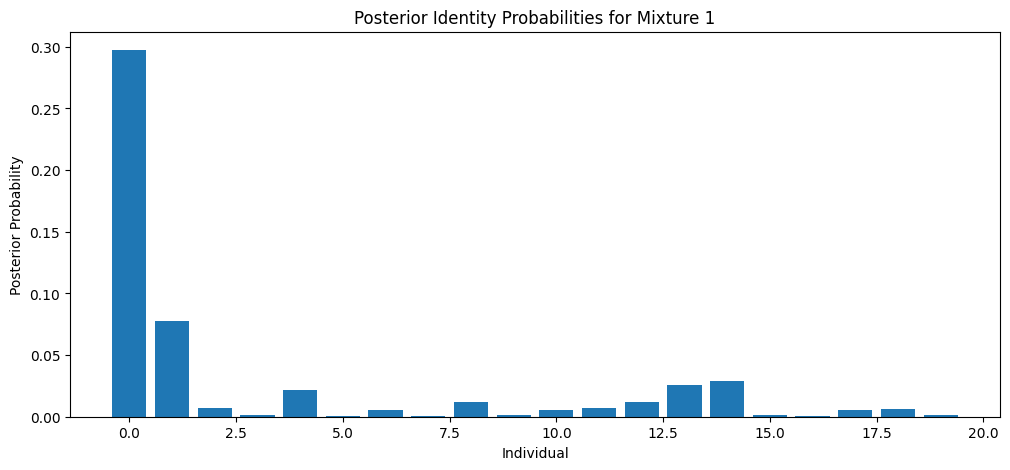

In [54]:
plt.figure(figsize=(12,5))

plt.bar(range(20), posterior[0][:20])

plt.title("Posterior Identity Probabilities for Mixture 1")
plt.xlabel("Individual")
plt.ylabel("Posterior Probability")

plt.savefig(
    r"C:\Users\PC\figures\posterior_identity_probabilities_mixture1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

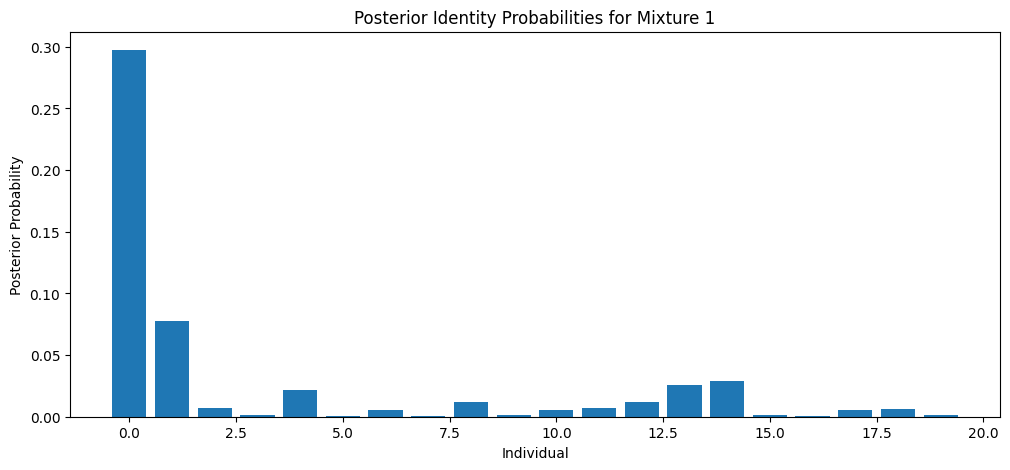

In [55]:
plt.figure(figsize=(12,5))

plt.bar(range(20), posterior[0][:20])

plt.title("Posterior Identity Probabilities for Mixture 1")
plt.xlabel("Individual")
plt.ylabel("Posterior Probability")

plt.savefig(
    r"C:\Users\PC\figures\posterior_identity_probabilities_mixture1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [56]:
from sklearn.metrics import roc_curve, auc

true_labels = []
scores = []

for i in range(reference.shape[0]):

    similarity_scores = cosine_similarity(
        degraded[:, i].reshape(1, -1),
        reference
    )[0]

    for j, score in enumerate(similarity_scores):

        if i == j:
            true_labels.append(1)
        else:
            true_labels.append(0)

        scores.append(score)

true_labels = np.array(true_labels)
scores = np.array(scores)

fpr, tpr, thresholds = roc_curve(true_labels, scores)

roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

AUC: 0.6781090909090909


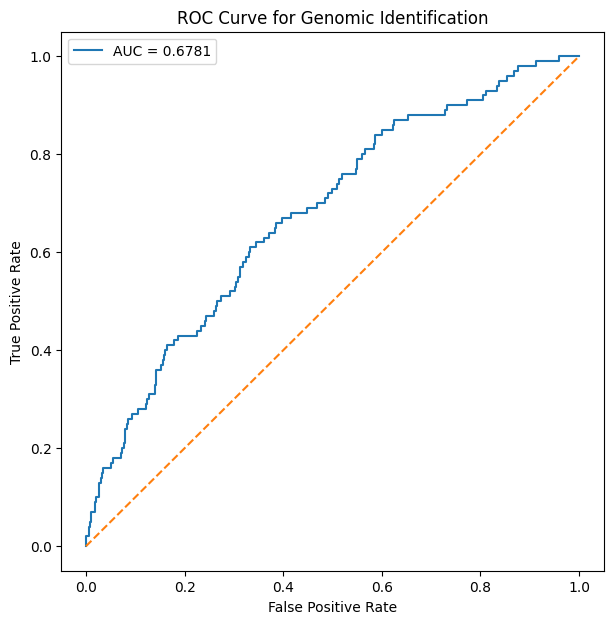

In [57]:
plt.figure(figsize=(7,7))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve for Genomic Identification")

plt.legend()

plt.savefig(
    r"C:\Users\PC\figures\roc_curve_genomic_identification.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

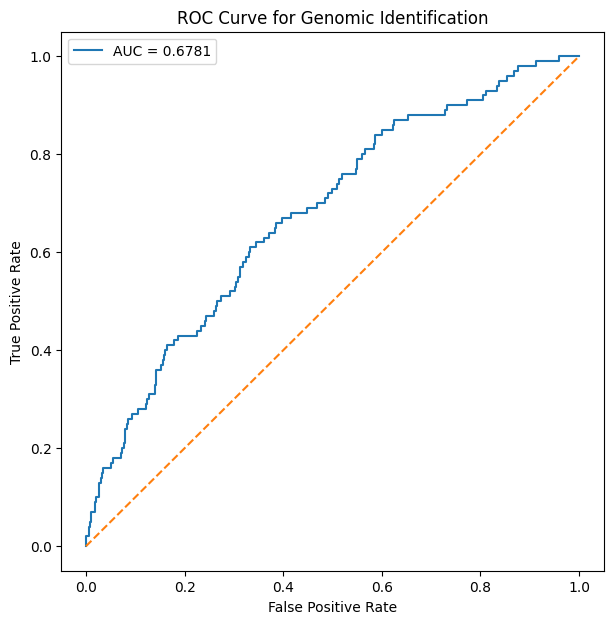

In [58]:
plt.figure(figsize=(7,7))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve for Genomic Identification")

plt.legend()

plt.savefig(
    r"C:\Users\PC\figures\roc_curve_genomic_identification.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [59]:
import pandas as pd

panel_url = "https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/release/20130502/integrated_call_samples_v3.20130502.ALL.panel"

panel = pd.read_csv(panel_url, sep="\t")

panel.head()

,sample,pop,super_pop,gender,Unnamed: 4,Unnamed: 5
0,HG00096,GBR,EUR,male,NaN,NaN
1,HG00097,GBR,EUR,female,NaN,NaN
2,HG00099,GBR,EUR,female,NaN,NaN
3,HG00100,GBR,EUR,female,NaN,NaN
4,HG00101,GBR,EUR,male,NaN,NaN


In [60]:
sample_ids = vcf["samples"][:100]

sample_metadata = panel[panel["sample"].isin(sample_ids)]

sample_metadata.head()

,sample,pop,super_pop,gender,Unnamed: 4,Unnamed: 5
0,HG00096,GBR,EUR,male,NaN,NaN
1,HG00097,GBR,EUR,female,NaN,NaN
2,HG00099,GBR,EUR,female,NaN,NaN
3,HG00100,GBR,EUR,female,NaN,NaN
4,HG00101,GBR,EUR,male,NaN,NaN


In [61]:
print(sample_metadata.shape)
print(sample_metadata["pop"].value_counts())

(100, 6)
pop
GBR    83
FIN    17
Name: count, dtype: int64


In [62]:
from sklearn.decomposition import PCA

X = gn.T

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

pca_df = pd.DataFrame({
    "PC1": pca_result[:, 0],
    "PC2": pca_result[:, 1],
    "sample": sample_ids
})

pca_df = pca_df.merge(panel, on="sample", how="left")

pca_df.head()

,PC1,PC2,sample,pop,super_pop,gender,Unnamed: 4,Unnamed: 5
0,-1.256344,-6.319078,HG00096,GBR,EUR,male,NaN,NaN
1,-3.044381,-2.823795,HG00097,GBR,EUR,female,NaN,NaN
2,-11.223991,4.496724,HG00099,GBR,EUR,female,NaN,NaN
3,15.274724,4.364857,HG00100,GBR,EUR,female,NaN,NaN
4,4.048441,-5.873287,HG00101,GBR,EUR,male,NaN,NaN


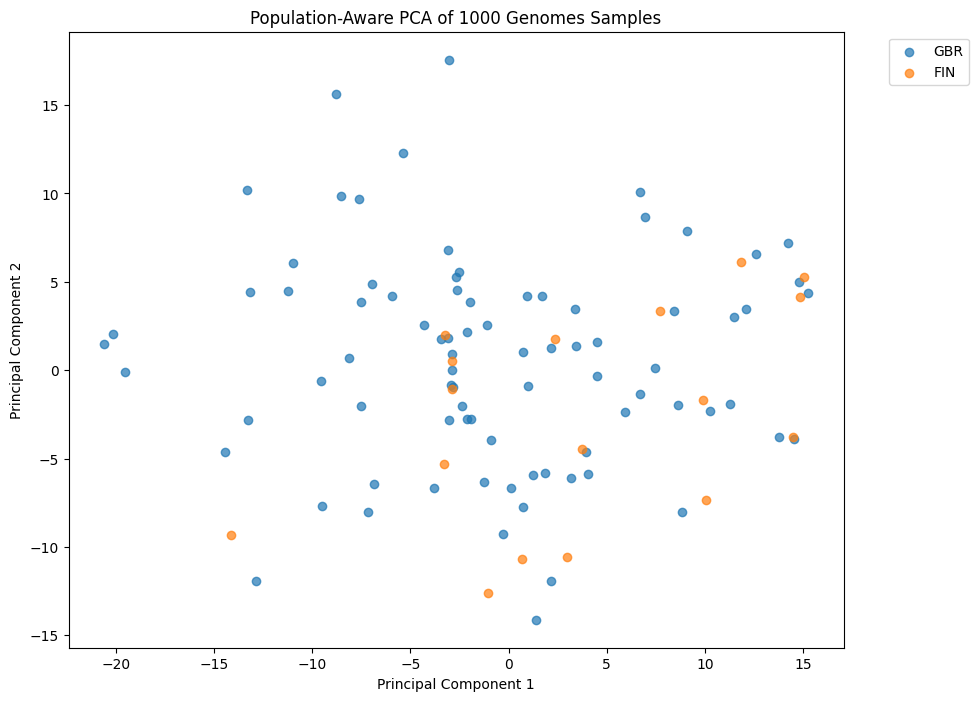

In [63]:
plt.figure(figsize=(10,8))

for pop in pca_df["pop"].dropna().unique():
    subset = pca_df[pca_df["pop"] == pop]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=pop,
        alpha=0.7
    )

plt.title("Population-Aware PCA of 1000 Genomes Samples")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.savefig(
    r"C:\Users\PC\figures\population_aware_pca.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [64]:
# Use more individuals for ancestry classification
gt_ancestry = vcf["calldata/GT"][:10000, :1000]
gn_ancestry = gt_ancestry[:, :, 0] + gt_ancestry[:, :, 1]

X = gn_ancestry.T
sample_ids = vcf["samples"][:1000]

ancestry_df = pd.DataFrame({
    "sample": sample_ids
})

ancestry_df = ancestry_df.merge(panel[["sample", "super_pop", "pop"]], on="sample", how="left")

print(ancestry_df["super_pop"].value_counts())
print(X.shape)

super_pop
EUR    297
EAS    297
AMR    283
AFR    115
SAS      8
Name: count, dtype: int64
(1000, 10000)


In [65]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

y = ancestry_df["super_pop"].values

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.25,
    random_state=42,
    stratify=y_encoded
)

clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Ancestry inference accuracy:", accuracy)
print("Classes:", encoder.classes_)

Ancestry inference accuracy: 0.808
Classes: ['AFR' 'AMR' 'EAS' 'EUR' 'SAS']


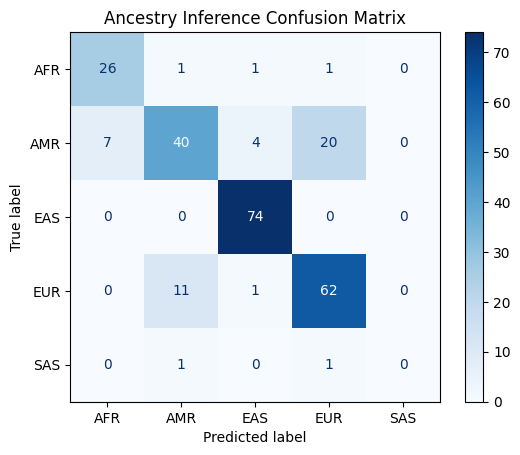

In [66]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Ancestry Inference Confusion Matrix")

plt.savefig(
    r"C:\Users\PC\figures\ancestry_inference_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [67]:
!pip install umap-learn

Defaulting to user installation because normal site-packages is not writeable


In [68]:
import umap
import matplotlib.pyplot as plt

X = gn_ancestry.T

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    random_state=42
)

embedding = reducer.fit_transform(X)

print(embedding.shape)

C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(1000, 2)


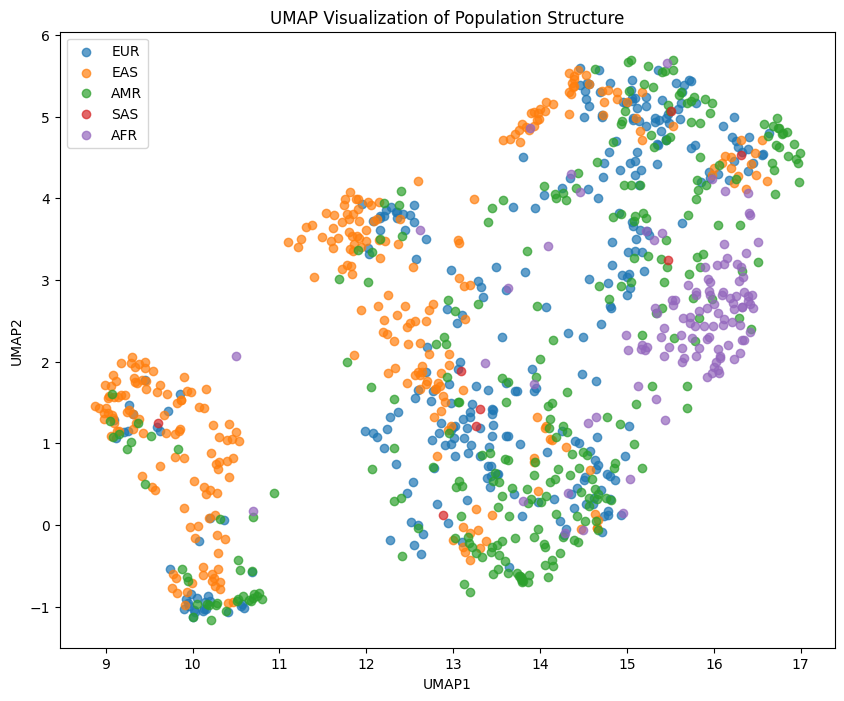

In [69]:
plt.figure(figsize=(10,8))

for pop in ancestry_df["super_pop"].unique():

    subset = ancestry_df["super_pop"] == pop

    plt.scatter(
        embedding[subset, 0],
        embedding[subset, 1],
        label=pop,
        alpha=0.7
    )

plt.title("UMAP Visualization of Population Structure")

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.legend()

plt.savefig(
    r"C:\Users\PC\figures\population_umap_structure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [70]:
plt.savefig(
    r"C:\Users\PC\figures\population_umap_structure.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [71]:
plt.show()

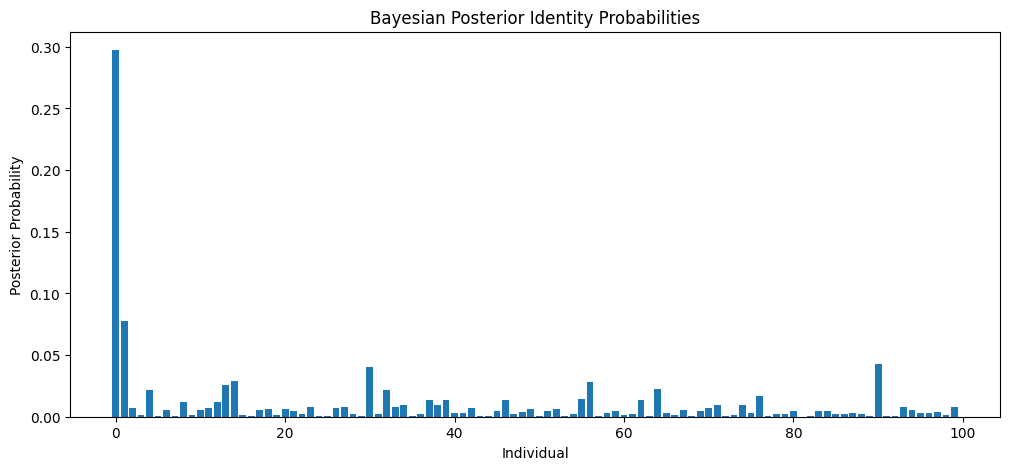

Posterior sum: 0.9999999999999999


In [72]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import softmax

scores = mix_similarity[0]
temperature = 0.05

posterior = softmax(scores / temperature)
plt.figure(figsize=(12,5))

plt.bar(range(len(posterior)), posterior)

plt.title("Bayesian Posterior Identity Probabilities")
plt.xlabel("Individual")
plt.ylabel("Posterior Probability")

plt.savefig(
    r"C:\Users\PC\figures\bayesian_posterior_identity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Posterior sum:", posterior.sum())

Posterior entropy: 3.3564488355249127


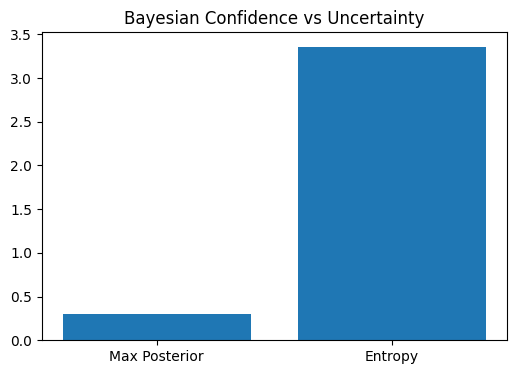

In [73]:
from scipy.stats import entropy
posterior_entropy = entropy(posterior)

print("Posterior entropy:", posterior_entropy)
max_prob = posterior.max()

plt.figure(figsize=(6,4))

plt.bar(
    ["Max Posterior", "Entropy"],
    [max_prob, posterior_entropy]
)

plt.title("Bayesian Confidence vs Uncertainty")

plt.savefig(
    r"C:\Users\PC\figures\bayesian_uncertainty_metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Max posterior probability: 0.2973529932403657
Posterior entropy: 3.3564488355249127


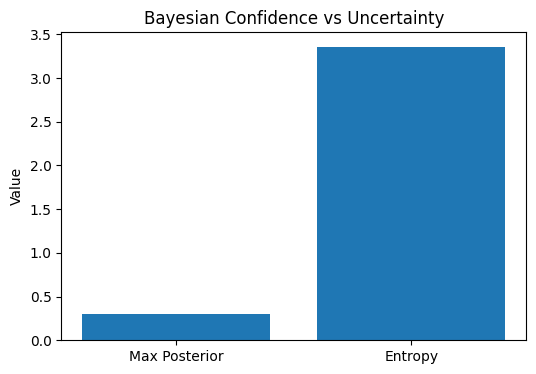

In [74]:
from scipy.stats import entropy
import matplotlib.pyplot as plt

posterior_entropy = entropy(posterior)
max_prob = posterior.max()

print("Max posterior probability:", max_prob)
print("Posterior entropy:", posterior_entropy)

plt.figure(figsize=(6,4))

plt.bar(
    ["Max Posterior", "Entropy"],
    [max_prob, posterior_entropy]
)

plt.title("Bayesian Confidence vs Uncertainty")
plt.ylabel("Value")

plt.savefig(
    r"C:\Users\PC\figures\bayesian_uncertainty_metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [75]:
plt.savefig(
    r"C:\Users\PC\figures\bayesian_identity_uncertainty.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

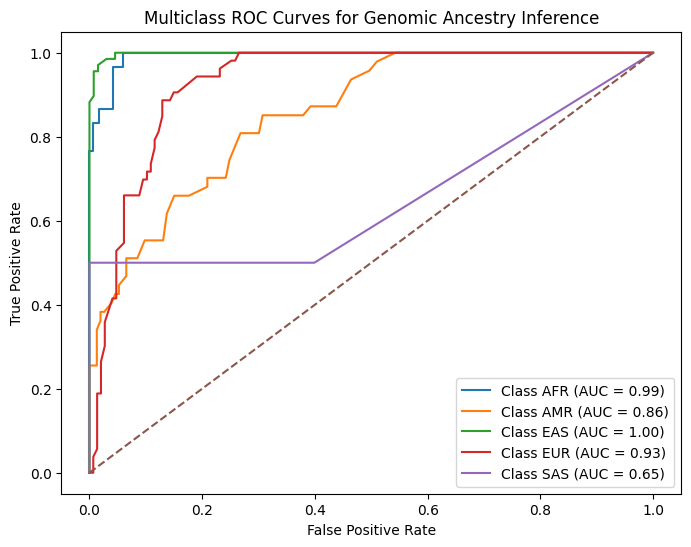

In [76]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Binarize labels
y_bin = label_binarize(y, classes=np.unique(y))

X_train, X_test, y_train_bin, y_test_bin = train_test_split(
    X,
    y_bin,
    test_size=0.2,
    random_state=42
)

clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

clf.fit(X_train, np.argmax(y_train_bin, axis=1))

y_score = clf.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i in range(y_bin.shape[1]):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"Class {encoder.classes_[i]} (AUC = {roc_auc:.2f})"
    )

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Multiclass ROC Curves for Genomic Ancestry Inference")

plt.legend()

plt.savefig(
    r"C:\Users\PC\figures\ancestry_multiclass_roc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

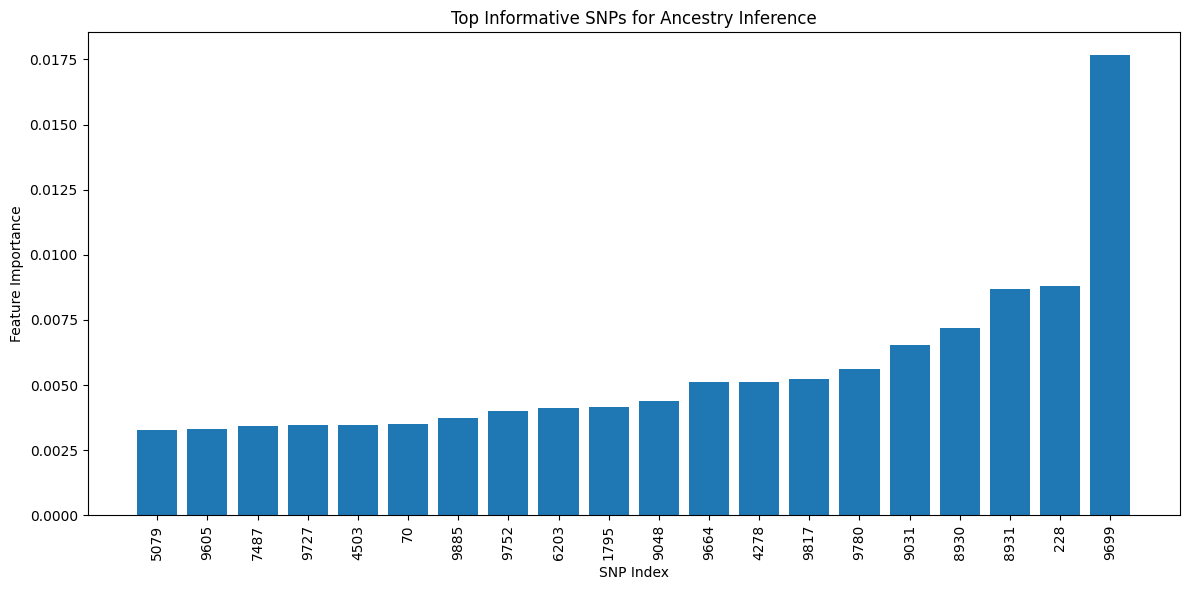

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

importance = clf.feature_importances_

top_idx = np.argsort(importance)[-20:]

top_scores = importance[top_idx]

plt.figure(figsize=(12,6))

plt.bar(range(len(top_scores)), top_scores)

plt.xticks(
    range(len(top_scores)),
    top_idx,
    rotation=90
)

plt.title("Top Informative SNPs for Ancestry Inference")

plt.xlabel("SNP Index")

plt.ylabel("Feature Importance")

plt.tight_layout()

plt.savefig(
    r"C:\Users\PC\figures\top_informative_snps.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [78]:
import pandas as pd

summary_results = pd.DataFrame({
    "Experiment": [
        "DNA degradation identity matching",
        "Mixed DNA entropy analysis",
        "Bayesian identity inference",
        "Ancestry inference classifier",
        "Explainable SNP importance"
    ],
    "Method": [
        "Cosine similarity",
        "Entropy-based uncertainty",
        "Posterior probability estimation",
        "Random Forest",
        "Feature importance"
    ],
    "Main Finding": [
        "Identity matching remained robust up to ~50% SNP dropout",
        "Balanced 50/50 mixtures produced the highest uncertainty",
        "Posterior probabilities quantified confidence in identity assignment",
        "Ancestry classifier achieved ~81% accuracy",
        "Top SNPs contributed most strongly to ancestry discrimination"
    ]
})

summary_results.to_csv(
    r"C:\Users\PC\results\summary_results.csv",
    index=False
)

summary_results

,Experiment,Method,Main Finding
0,DNA degradation identity matching,Cosine similarity,Identity matching remained robust up to ~50% S...
1,Mixed DNA entropy analysis,Entropy-based uncertainty,Balanced 50/50 mixtures produced the highest u...
2,Bayesian identity inference,Posterior probability estimation,Posterior probabilities quantified confidence ...
3,Ancestry inference classifier,Random Forest,Ancestry classifier achieved ~81% accuracy
4,Explainable SNP importance,Feature importance,Top SNPs contributed most strongly to ancestry...


In [79]:
import numpy as np

eur_idx = ancestry_df[ancestry_df["super_pop"] == "EUR"].index
afr_idx = ancestry_df[ancestry_df["super_pop"] == "AFR"].index

eur_sample = gn_ancestry[:, eur_idx[0]]
afr_sample = gn_ancestry[:, afr_idx[0]]

admixed_genome = (
    0.5 * eur_sample +
    0.5 * afr_sample
)

print(admixed_genome.shape)

(10000,)


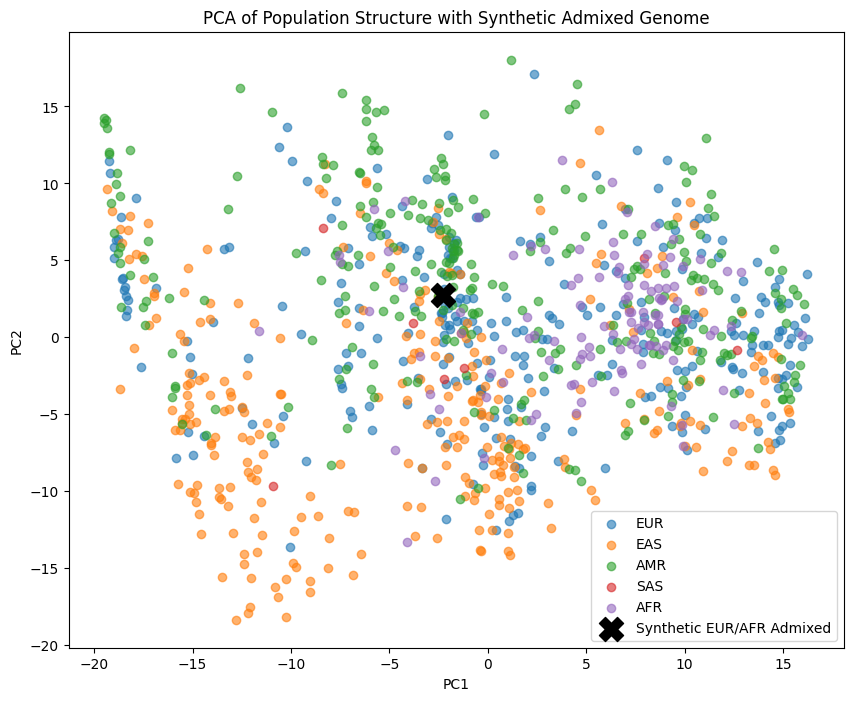

In [80]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_real = gn_ancestry.T

X_combined = np.vstack([
    X_real,
    admixed_genome
])

pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_combined)

real_pca = pca_result[:-1]
admixed_pca = pca_result[-1]

plt.figure(figsize=(10,8))

for pop in ancestry_df["super_pop"].unique():

    subset = ancestry_df["super_pop"] == pop

    plt.scatter(
        real_pca[subset, 0],
        real_pca[subset, 1],
        label=pop,
        alpha=0.6
    )

plt.scatter(
    admixed_pca[0],
    admixed_pca[1],
    color="black",
    marker="X",
    s=300,
    label="Synthetic EUR/AFR Admixed"
)

plt.title("PCA of Population Structure with Synthetic Admixed Genome")

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.legend()

plt.savefig(
    r"C:\Users\PC\figures\synthetic_admixed_pca.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

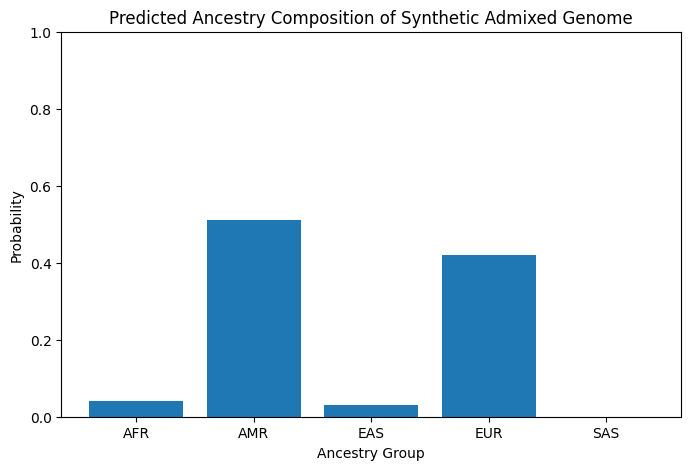

{'AFR': np.float64(0.04), 'AMR': np.float64(0.51), 'EAS': np.float64(0.03), 'EUR': np.float64(0.42), 'SAS': np.float64(0.0)}


In [81]:
admixed_prediction = clf.predict_proba(
    admixed_genome.reshape(1, -1)
)

probs = admixed_prediction[0]

labels = encoder.classes_

plt.figure(figsize=(8,5))

plt.bar(labels, probs)

plt.title("Predicted Ancestry Composition of Synthetic Admixed Genome")

plt.xlabel("Ancestry Group")

plt.ylabel("Probability")

plt.ylim(0, 1)

plt.savefig(
    r"C:\Users\PC\figures\admixed_ancestry_probabilities.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(dict(zip(labels, probs)))

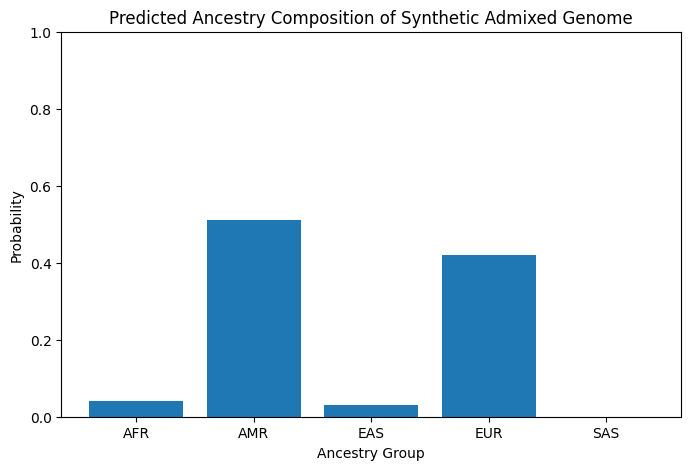

{'AFR': np.float64(0.04), 'AMR': np.float64(0.51), 'EAS': np.float64(0.03), 'EUR': np.float64(0.42), 'SAS': np.float64(0.0)}


In [82]:
admixed_prediction = clf.predict_proba(
    admixed_genome.reshape(1, -1)
)

probs = admixed_prediction[0]
labels = encoder.classes_

plt.figure(figsize=(8,5))
plt.bar(labels, probs)

plt.title("Predicted Ancestry Composition of Synthetic Admixed Genome")
plt.xlabel("Ancestry Group")
plt.ylabel("Probability")
plt.ylim(0, 1)

plt.savefig(
    r"C:\Users\PC\figures\admixed_ancestry_probabilities.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(dict(zip(labels, probs)))

In [84]:
!pip install graphviz

Defaulting to user installation because normal site-packages is not writeable


In [85]:
!pip install pydot

Defaulting to user installation because normal site-packages is not writeable


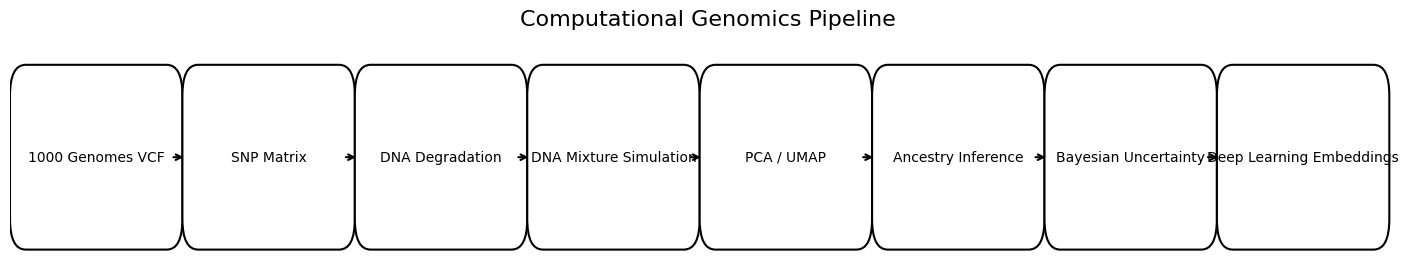

In [87]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

steps = [
    "1000 Genomes VCF",
    "SNP Matrix",
    "DNA Degradation",
    "DNA Mixture Simulation",
    "PCA / UMAP",
    "Ancestry Inference",
    "Bayesian Uncertainty",
    "Deep Learning Embeddings"
]

plt.figure(figsize=(18, 3))
ax = plt.gca()
ax.axis("off")

x_positions = range(len(steps))

for i, step in enumerate(steps):
    box = FancyBboxPatch(
        (i * 2.2, 0),
        1.8,
        0.8,
        boxstyle="round,pad=0.2",
        linewidth=1.5,
        edgecolor="black",
        facecolor="white"
    )
    ax.add_patch(box)
    ax.text(
        i * 2.2 + 0.9,
        0.4,
        step,
        ha="center",
        va="center",
        fontsize=10
    )

    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(i * 2.2 + 2.05, 0.4),
            xytext=(i * 2.2 + 1.85, 0.4),
            arrowprops=dict(arrowstyle="->", linewidth=1.5)
        )

ax.set_xlim(-0.2, len(steps) * 2.2)
ax.set_ylim(-0.3, 1.2)

plt.title("Computational Genomics Pipeline", fontsize=16)

plt.savefig(
    r"C:\Users\PC\figures\genomic_pipeline_diagram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

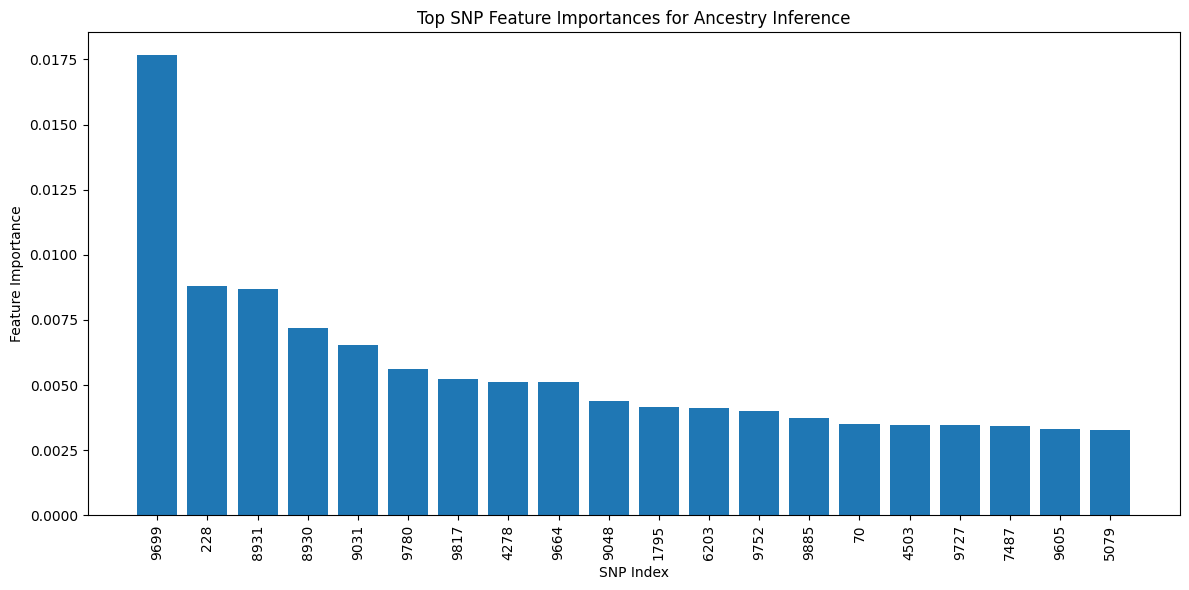

,SNP,importance
9699,9699,0.017659
228,228,0.008818
8931,8931,0.008703
8930,8930,0.007180
9031,9031,0.006527


In [88]:
import pandas as pd
import matplotlib.pyplot as plt

importance = clf.feature_importances_

importance_df = pd.DataFrame({
    "SNP": np.arange(len(importance)),
    "importance": importance
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

top_snps = importance_df.head(20)

plt.figure(figsize=(12,6))

plt.bar(
    top_snps["SNP"].astype(str),
    top_snps["importance"]
)

plt.xticks(rotation=90)

plt.title("Top SNP Feature Importances for Ancestry Inference")

plt.xlabel("SNP Index")
plt.ylabel("Feature Importance")

plt.tight_layout()

plt.savefig(
    r"C:\Users\PC\figures\snp_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

top_snps.head()

Dropout 10% -> Accuracy: 0.957
Dropout 30% -> Accuracy: 0.910
Dropout 50% -> Accuracy: 0.750
Dropout 70% -> Accuracy: 0.456
Dropout 90% -> Accuracy: 0.290


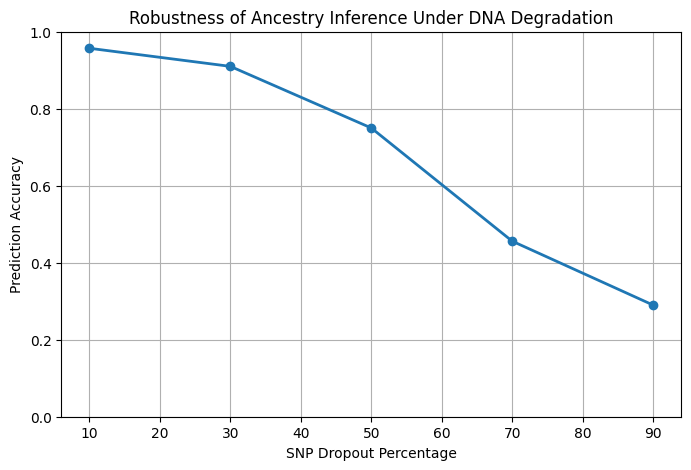

In [91]:
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

dropout_levels = [0.1, 0.3, 0.5, 0.7, 0.9]
accuracies = []

X_original = X.copy()

for dropout in dropout_levels:
    X_degraded = X_original.copy()

    mask = np.random.rand(*X_degraded.shape) < dropout
    X_degraded[mask] = 0

    y_pred = clf.predict(X_degraded)

    acc = accuracy_score(y_encoded, y_pred)

    accuracies.append(acc)

    print(f"Dropout {dropout*100:.0f}% -> Accuracy: {acc:.3f}")

plt.figure(figsize=(8,5))

plt.plot(
    [d*100 for d in dropout_levels],
    accuracies,
    marker="o",
    linewidth=2
)

plt.xlabel("SNP Dropout Percentage")
plt.ylabel("Prediction Accuracy")
plt.title("Robustness of Ancestry Inference Under DNA Degradation")
plt.ylim(0, 1)
plt.grid(True)

plt.savefig(
    r"C:\Users\PC\figures\ancestry_robustness_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

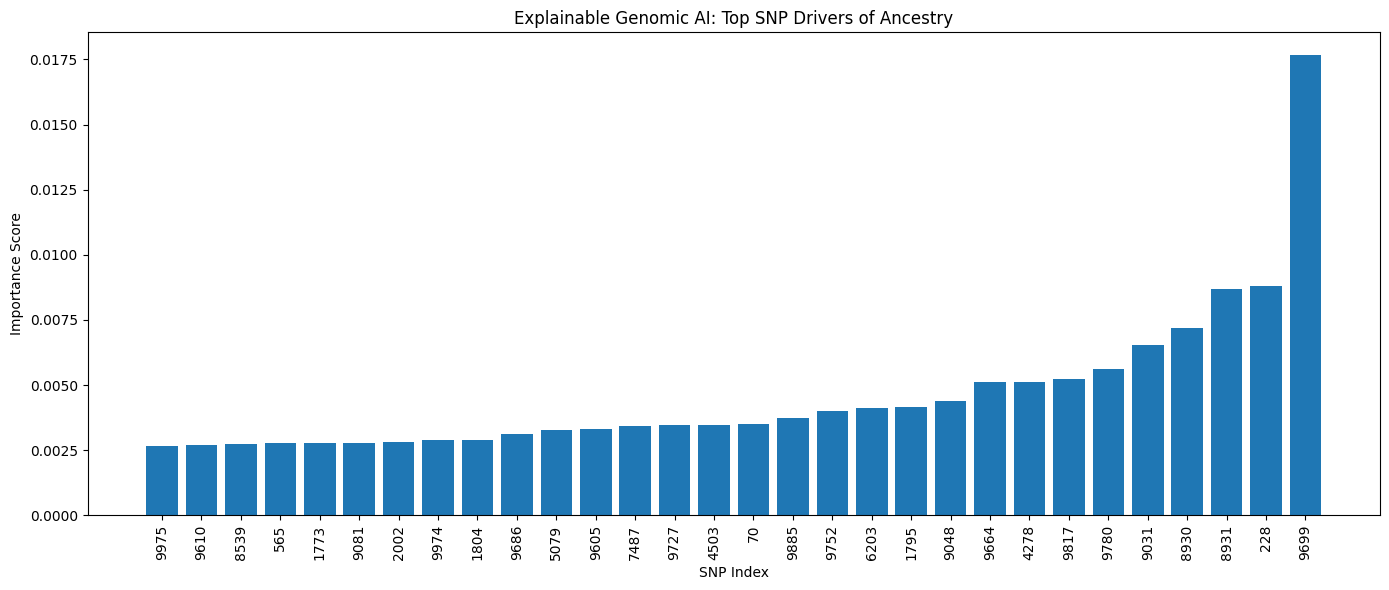

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

importance = clf.feature_importances_

top_n = 30

top_idx = np.argsort(importance)[-top_n:]

top_scores = importance[top_idx]

plt.figure(figsize=(14,6))

plt.bar(range(top_n), top_scores)

plt.xticks(
    range(top_n),
    top_idx,
    rotation=90
)

plt.xlabel("SNP Index")
plt.ylabel("Importance Score")

plt.title("Explainable Genomic AI: Top SNP Drivers of Ancestry")

plt.tight_layout()

plt.savefig(
    r"C:\Users\PC\figures\explainable_snp_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()